# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:


# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head(5)


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:

# mostrar las primeras 5 filas de users
users.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:

# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)


plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())


id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?

Tabla users
- city (~11.7% nulos):
Proporción media de valores faltantes, puede afectar análisis geográficos y segmentación.
Acción: imputar (ej. categoría “Unknown”) o investigar fuente.

- churn_date (~88.4% nulos):
Muy alta proporción de nulos, pero consistente con la lógica del negocio (solo usuarios que se dieron de baja tienen fecha).
Acción: mantener nulos, no es un error sino información implícita de no churn.

Tabla usage
- date (~0.13% nulos):
Presenta una proporción muy baja de valores faltantes, lo que indica errores puntuales de registro.
Acción: imputar o eliminar registros, impacto mínimo.

- duration (~55.2% nulos):
Más de la mitad de los valores son nulos, lo que sugiere que no aplica para todos los tipos de registros (posible dependencia con type, ej. solo llamadas).
Acción: investigar relación con type; si es MAR, mantener como nulos.

- length (~44.7% nulos):
Alta proporción de nulos, posiblemente porque solo aplica a mensajes de texto.
Acción: validar dependencia con type; mantener nulos si corresponde a comportamiento estructural.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` no presenta valores inconsistentes: todos los identificadores están dentro de un rango lógico (10000–13999), son numéricos, no hay valores faltantes y su distribución es uniforme (media ≈ mediana).
Se comporta correctamente como identificador único, no requiere limpieza.

- La columna `age` La columna age contiene un sentinel (-999) que distorsiona la distribución y debe reemplazarse por NaN antes del análisis.

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000




- Las columnas `id` y `user_id`user_id no presentan valores inválidos: ambos tienen rangos consistentes (id: 1–40000, user_id: 10000–13999), sin valores negativos ni nulos. Además, las medias coinciden con las medianas, lo que sugiere distribuciones uniformes.
Funcionan correctamente como identificadores y no requieren limpieza.

- La columna `duration`tiene valores entre 0 y 120 minutos, todos no negativos; presenta una dispersión moderada (std ≈ 6.8) y una diferencia notable entre la mediana (3.5) y el máximo (120), lo que indica la presencia de valores extremos. Adicionalmente, el bajo conteo frente al total evidencia una alta proporción de nulos.
No hay valores inválidos, pero sí posibles outliers y muchos nulos que deben analizarse en función del tipo de evento (type).

- La columna `lenght` Tiene valores entre 0 y 1490 caracteres, con una desviación alta (std ≈ 56); el máximo es considerablemente alto frente a la mediana (~50). No hay valores inválidos, pero existen outliers claros en mensajes largos que deben revisarse.



In [14]:

# explorar columnas categóricas de users

columnas_user = ['city', 'plan']

for col in columnas_user:
    print(col)
    
    # Valores únicos
    print("Valores únicos:")
    print(users[col].unique())
    
    # Frecuencia
    print("Frecuencia absoluta")
    print(users[col].value_counts(dropna=False))
    
    print("Frecuencia relativa")
    print(users[col].value_counts(normalize=True, dropna=False))
    
    #Buscar posibles sentinels
    print("Posibles sentinels:")
    posibles = users[col].isin(['?', 'unknown', 'NA', 'none', ''])
    print(users[col][posibles].value_counts(dropna=False))


    print("\n" + "-"*40 + "\n")


city
Valores únicos:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
Frecuencia absoluta
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Frecuencia relativa
Bogotá      0.20200
CDMX        0.18250
Medellín    0.15400
NaN         0.11725
GDL         0.11250
Cali        0.10600
MTY         0.10175
?           0.02400
Name: city, dtype: float64
Posibles sentinels:
?    96
Name: city, dtype: int64

----------------------------------------

plan
Valores únicos:
['Basico' 'Premium']
Frecuencia absoluta
Basico     2595
Premium    1405
Name: plan, dtype: int64
Frecuencia relativa
Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64
Posibles sentinels:
Series([], Name: plan, dtype: int64)

----------------------------------------



- La columna `city` presenta un sentinel claro ("?") con 96 registros (~2.4%), el cual representa un valor inválido o desconocido que no corresponde a una ciudad real.

- Adicionalmente, existe una proporción relevante de valores nulos (~11.7%), lo que indica información faltante.

- La columna `plan` o presenta valores inválidos ni sentinels; únicamente contiene categorías válidas (Basico y Premium) con consistencia en formato y sin valores atípicos.

In [15]:
# explorar columna categórica de usage

print("Valores únicos:")
print(usage['type'].unique())
print()

# 2. Frecuencia absoluta (incluyendo NaN)
print("Frecuencia absoluta:")
print(usage['type'].value_counts(dropna=False))
print()

# 3. Frecuencia relativa
print("Frecuencia relativa:")
print(usage['type'].value_counts(normalize=True, dropna=False))
print()

# 4. Buscar sentinels explícitos
sentinels = ['?', 'unknown', 'NA', 'none', '']
mask_sentinels = usage['type'].isin(sentinels)

print("Posibles sentinels encontrados:")
print(usage.loc[mask_sentinels, 'type'].value_counts(dropna=False))
print()

# 5. Detectar inconsistencias (espacios extra)
print("Valores con espacios extra:")
mask_espacios = usage['type'].str.strip() != usage['type']
print(usage.loc[mask_espacios, 'type'].value_counts(dropna=False))
print()

# 6. Normalización para detectar duplicados semánticos (mayúsculas/minúsculas)
print("Frecuencia normalizada (lowercase):")
print(usage['type'].str.lower().value_counts(dropna=False))
print()

Valores únicos:
['call' 'text']

Frecuencia absoluta:
text    22092
call    17908
Name: type, dtype: int64

Frecuencia relativa:
text    0.5523
call    0.4477
Name: type, dtype: float64

Posibles sentinels encontrados:
Series([], Name: type, dtype: int64)

Valores con espacios extra:
Series([], Name: type, dtype: int64)

Frecuencia normalizada (lowercase):
text    22092
call    17908
Name: type, dtype: int64



- La columna `type` La columna type presenta dos categorías: text (55.23%) y call (44.77%), lo que indica una distribución relativamente equilibrada entre ambos tipos de uso. Sin embargo, los mensajes de texto tienen una ligera mayor participación, lo que sugiere que son el tipo de actividad más frecuente en el dataset.
- No se identifican valores inválidos, sentinels ni inconsistencias de formato (como espacios adicionales o diferencias de capitalización), por lo que la variable es consistente y adecuada para segmentar el comportamiento de uso.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [20]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [21]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
# Revisar los años presentes en `reg_date` de usage
usage['reg_date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

In [18]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- Sí, se identifican años fuera del rango esperado en la columna reg_date:
La mayoría de los datos están entre 2022 y 2024, lo cual es consistente.
Sin embargo, aparecen 40 registros en 2026, que corresponde a un año futuro respecto al alcance del dataset (hasta 2024).
En la tabla usage, la columna date está completamente concentrada en 2024, por lo que no presenta años inválidos.
- ¿Qué harías con ellas?
Para los registros en 2026 (reg_date):
Validar si corresponden a errores de captura.
Si son incorrectos: Excluirlos del análisis, o Convertirlos a NaT para no afectar análisis temporal.

Para la columna date en usage:
No se requieren acciones, ya que todos los registros están dentro del año esperado (2024).

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [25]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [26]:
# Reemplazar "?" por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(users['city'].value_counts(dropna=False))

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [31]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [32]:
# Verificación MAR en usage (Missing At Random) para duration
print("Nulos en duration por type:")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().mean()))


Nulos en duration por type:
type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [33]:


# Verificación MAR en usage (Missing At Random) para length


print("\nNulos en length por type:")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().mean()))




Nulos en length por type:
type
call    0.99933
text    0.00000
Name: length, dtype: float64



Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`


Se observa que los valores nulos dependen completamente de la variable type. En particular, para los registros de tipo call, aproximadamente el 99.93% de los valores son nulos, mientras que para text no se presentan valores nulos.

Esto confirma que la ausencia de datos no es aleatoria, sino que está determinada por el tipo de actividad. 

En consecuencia, los valores faltantes corresponden a información que no aplica según el tipo de uso, por lo que se clasifican como datos MAR (Missing At Random).

Dado que estos valores tienen una justificación lógica, se decide mantener los valores nulos sin imputación para evitar introducir sesgos en el análisis.


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [34]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario

usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()


# observar resultado
usage_agg.head(3)



,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [35]:
# Renombrar columnas

usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
}).reset_index()

# observar resultado
usage_agg.head(3)

,index,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,0,10000,7,3,23.70
1,1,10001,5,10,33.18
2,2,10002,5,2,10.74


In [36]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,index,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,0.0,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,1.0,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [37]:
# Resumen estadístico de las columnas numéricas

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

print(user_profile[columnas_numericas].describe())

               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.136000       5.524381       4.478120             23.317054
std      17.689919       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [39]:
# Distribución porcentual del tipo de plan
print(user_profile['plan'].value_counts(normalize=True))

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

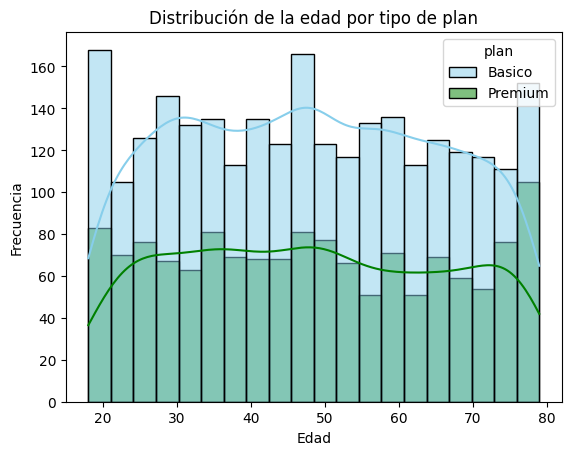

In [52]:
# Histograma para visualizar la edad (age)

sns.histplot(
    data=user_profile,
    x="age",
    hue="plan",
    bins=20,
    palette=["skyblue", "green"],
    kde=True
)
plt.title('Distribución de la edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 

La distribución de la edad es aproximadamente uniforme, ya que los valores se distribuyen de manera relativamente equilibrada a lo largo del rango sin presentar una concentración clara en un punto central.

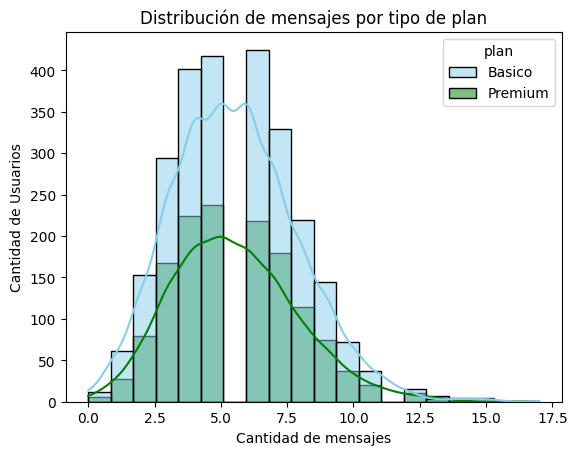

In [57]:
# Histograma para visualizar la cant_mensajes

sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    bins=20,
    palette=["skyblue", "green"],
    kde=True
)
plt.title('Distribución de mensajes por tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()


💡Insights: 
-  Los usuarios de ambos planes tienen una distribución de mensajes similar, pero el plan Premium se concentra ligeramente en niveles de uso moderados (4–7 mensajes), mientras que Básico presenta mayor dispersión y mayor volumen total.
-  Ambos planes:Distribución tipo asimétrica a la derecha (cola larga) → pocos usuarios con uso muy alto.
Pico principal entre 4 y 6 mensajes.

- Basico: Mayor volumen total (más usuarios).Mayor variabilidad, hay más usuarios de bajo y alto uso.

- Premium: Más concentrado, comportamiento más consistente. Menos extremos → menos usuarios con uso muy bajo o muy alto.

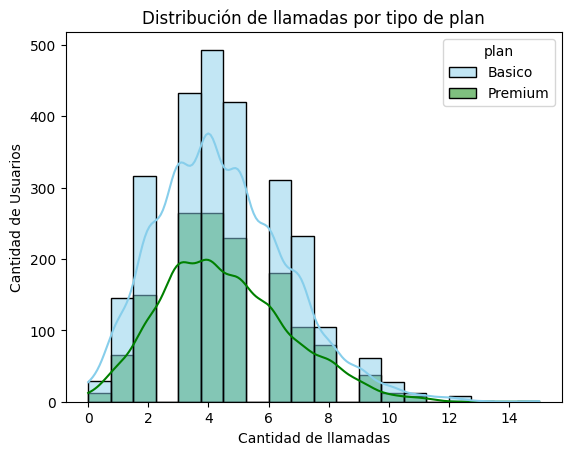

In [58]:


# Histograma para visualizar la cant_llamadas


sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    bins=20,
    palette=["skyblue", "green"],
    kde=True
)
plt.title('Distribución de llamadas por tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()




💡Insights: 
- La distribución de llamadas es prácticamente igual entre planes, pero el plan Premium tiene una mayor presencia relativa en niveles de uso medio‑alto (5–8 llamadas).
- Ambos planes muestran una distribución asimétrica a la derecha:Pico en 3–5 llamadas.Cola larga hacia usuarios de mayor uso (hasta ~12+ llamadas).
- Basico: Mayor volumen total (más usuarios).Más dispersión, incluye muchos usuarios de bajo y alto uso.
- Premium: Más concentrado en rangos medios-altos (4–7 llamadas). Menor presencia en extremos (especialmente muy bajo uso).
- los usuarios Premium tienden a un uso más intensivo y consistente de llamadas

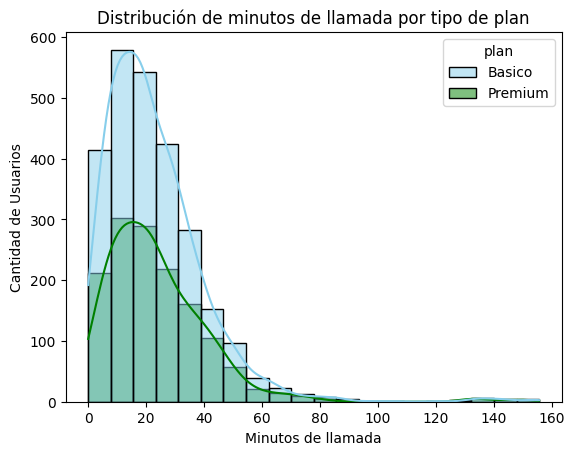

In [59]:
# Histograma para visualizar la cant_minutos_llamada

sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    bins=20,
    palette=["skyblue", "green"],
    kde=True
)
plt.title('Distribución de minutos de llamada por tipo de plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Cantidad de Usuarios')
plt.show()


💡Insights: 
-El consumo de minutos de llamada diferencia mejor a los usuarios Premium: estos muestran una mayor concentración en niveles más altos de consumo frente a los usuarios Básico.

- Ambos planes: Distribución asimétrica a la derecha, pocos usuarios con consumo muy alto (cola larga). Pico principal entre 10 y 30 minutos.

- Basico: Mayor volumen total. Mayor presencia en niveles bajos y medios. Más dispersión, muchos usuarios con consumo moderado.



Premium:

Mayor densidad relativa en consumos más altos (20–50 minutos).
Menor peso en niveles bajos → usuarios más intensivos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

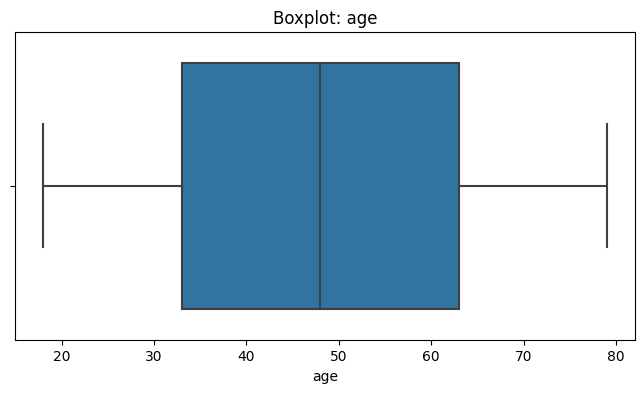

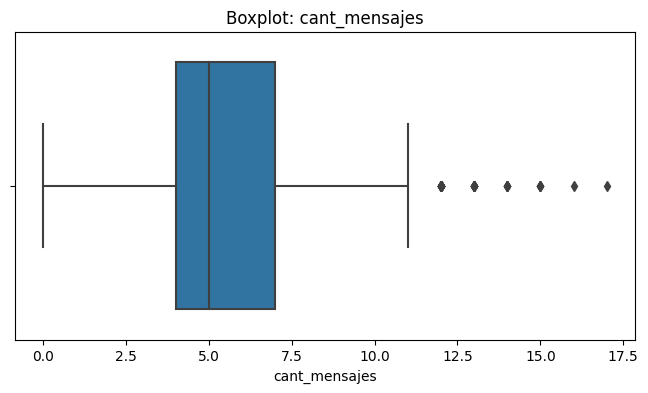

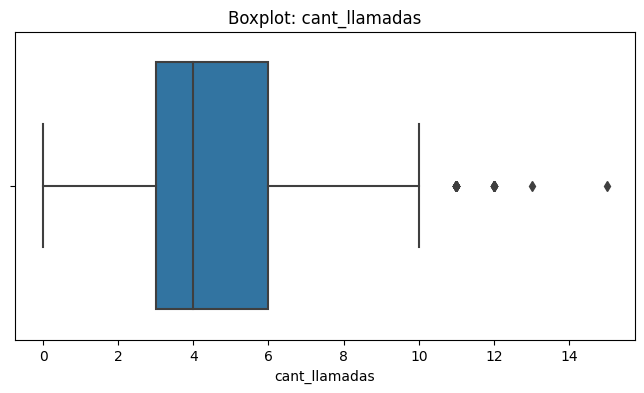

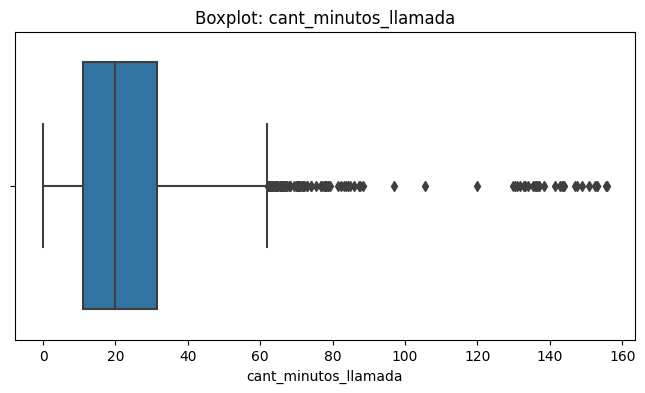

In [64]:

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()



💡Insights: 
- Age: No presenta outliers visibles; la distribución es bastante equilibrada y dentro de rangos normales (≈18–80), lo que indica buena calidad de datos tras limpieza.
- cant_mensajes: Sí presenta outliers altos (≈12–17 mensajes), lo que indica la existencia de heavy users de mensajería que consumen mucho más que el promedio.Distribución asimétrica a la derecha.
- cant_llamadas: presenta outliers (≈10–15 llamadas), aunque menos extremos que en mensajes. Hay usuarios intensivos, pero el comportamiento es más estable que en mensajes.
- cant_minutos_llamada: Presenta la mayor cantidad de outliers y más extremos (hasta ~150 minutos), con una fuerte asimetría.  Indica un segmento claro de heavy users de duración, que concentran gran parte del consumo.

In [67]:

# Calcular límites con el método IQR

columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    print(f"{col}")
    print("Límite inferior:", limite_inferior)
    print("Límite superior:", limite_superior)
    print()



cant_mensajes
Límite inferior: -0.5
Límite superior: 11.5

cant_llamadas
Límite inferior: -1.5
Límite superior: 10.5

cant_minutos_llamada
Límite inferior: -19.322500000000005
Límite superior: 61.8575



In [68]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Sí se deben mantener, porque representan usuarios reales con alto uso (heavy users) y no errores de captura. Eliminarlos eliminaría información clave de comportamiento.
- cant_llamadas: mantener o no outliers, porqué?  Sí se deben mantener, ya que los valores por encima del límite (~10.5) corresponden a usuarios intensivos, no a valores inválidos. Reflejan comportamiento legítimo del negocio.
- cant_minutos_llamada: mantener o no outliers, porqué? Se deben mantener, porque estos outliers (hasta ~150 minutos) representan el segmento más valioso: heavy users de consumo. Son datos reales y además clave para explicar el valor del plan Premium

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [69]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'
    )
)

In [70]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,index,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,0.0,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,1.0,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [71]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30,
    'Joven',
    np.where(
        user_profile['age'] < 60,
        'Adulto',
        'Adulto Mayor'
    )
)

In [72]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,index,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,0.0,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,1.0,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

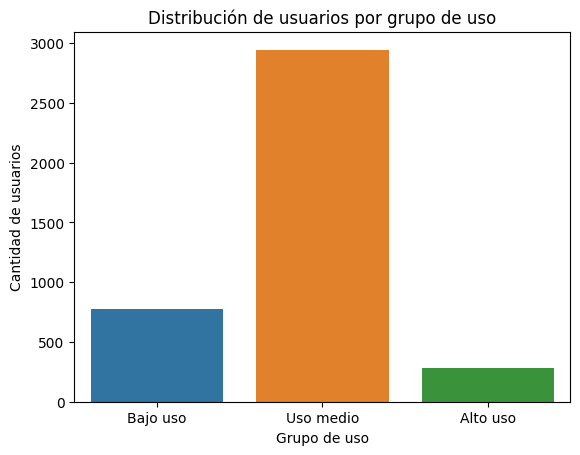

In [73]:

# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    order=['Bajo uso', 'Uso medio', 'Alto uso']
)

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()


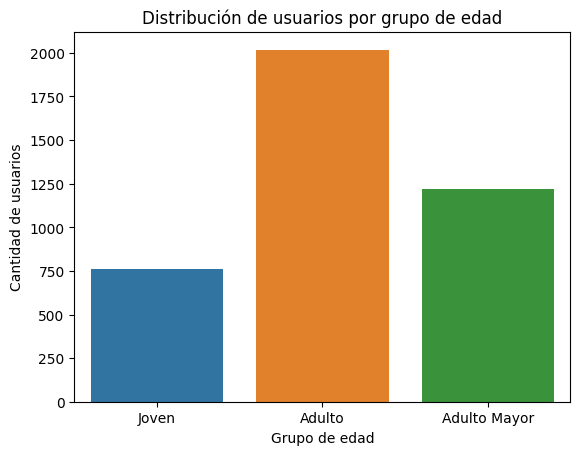

In [74]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x='grupo_edad',
    order=['Joven', 'Adulto', 'Adulto Mayor']
)

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

Se identificaron varios problemas de calidad:

Sentinels (valores inválidos): age contenía -999 → valor imposible.

Nulos relevantes:

city: ~11.7% de nulos + valores inválidos como "?"
churn_date: ~88% nulos (pero estructurales → usuarios activos)
duration (~55%) y length (~45%) → nulos estructurales (dependen de type)


Fechas fuera de rango:

reg_date tenía 40 registros en 2026 (~1%), fuera del periodo esperado.

Había mezcla de errores (sentinels), nulos estructurales y valores fuera de rango que requerían limpieza y validación.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

Por nivel de uso:

Bajo uso (~19%)
Poca actividad (mensajes y llamadas)
Baja contribución al negocio

Uso medio (~74%)
Mayoría de la base
Consumo moderado y estable

Alto uso (~7%)

Por edad:

Jóvenes (~19%)
Adultos (~50%) → segmento dominante
Adultos mayores (~31%)

No hay diferencias extremas por edad, pero, el consumo intensivo no depende tanto de edad sino de comportamiento

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

Usuarios de ALTO USO son los más valiosos, porque: Consumen más minutos (driver clave), Representan mayor potencial de ingresos, Están más alineados con el pl
an Premium

Usuarios de USO MEDIO son estratégicos, porque: Son la mayor base, Son el principal pool de conversión a alto valor

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

Se identificaron outliers en: 
Mensajes (≈12–17) → heavy users de mensajería
Llamadas (≈10–15) → usuarios intensivos
Minutos (≈60–150+) → más relevantes

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

Optimizar el plan Premium

Enfocarlo en: Más minutos (driver real), Beneficios para heavy users, No centrarse tanto en cantidad de eventos (mensajes/llamadas)

Estrategia de upgrade: Target: Usuarios de Uso medio → Alto uso

Acciones:
Ofertas personalizadas
Bundles de minutos
Incentivos por consumo

Activación de bajo uso: moverlos a uso medio

Acciones:
Promociones básicas
Planes más económicos / entrada

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

Se identificaron valores inválidos (sentinels) como -999 en la variable age y "?" en city, que afectaban la calidad de la información.
Existían valores nulos relevantes: city (~11.7%) y churn_date (~88%), además de nulos estructurales en duration y length por tipo de actividad.
Se detectaron fechas fuera de rango (año 2026) que no corresponden al periodo de análisis (2022–2024).

🔍 **Segmentos por Edad**

La población está compuesta principalmente por adultos (~50%), seguidos de adultos mayores (~31%) y una menor proporción de jóvenes (~19%).
No se observa una fuerte diferenciación del comportamiento por edad, lo que sugiere que el uso del servicio es transversal entre grupos etarios.

📊 **Segmentos por Nivel de Uso**

La mayoría de los usuarios se concentran en Uso medio (~74%), seguido por Bajo uso (~19%) y un grupo reducido de Alto uso (~7%).
Los usuarios de alto uso presentan patrones intensivos, especialmente en minutos de llamada, lo que indica mayor valor económico.

➡️ Esto sugiere que ...

El negocio está sustentado en una base amplia de usuarios de uso medio, pero el valor se concentra en un grupo pequeño de usuarios intensivos.
El principal diferenciador no es la cantidad de interacciones (mensajes o llamadas), sino la intensidad de uso (minutos consumidos).
Existe una oportunidad clara de crecimiento en migrar usuarios de uso medio a alto uso.

💡 **Recomendaciones**
Optimizar el plan Premium enfocándolo en beneficios asociados a minutos de consumo, que es donde se concentra el valor.
Diseñar estrategias de upgrade dirigidas a usuarios de uso medio, incentivando mayor consumo.
Implementar acciones de activación para usuarios de bajo uso mediante planes más simples o promociones.
Crear una estructura de planes escalonada (básico, medio, premium) alineada a los niveles de uso detectados.
Mantener y monitorear los usuarios de alto consumo, ya que representan el segmento más valioso del negocio.

El valor de ConnectaTel no está en cuántos eventos genera un usuario, sino en cuánto tiempo consume el servicio, lo que redefine la estrategia hacia modelos centrados en intensidad de uso.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`